In [1]:
import sys
sys.path.insert(0, r"C:\Users\Andrei\HonorsProject\pytspl")
import pytspl
from pytspl import list_datasets
from pytspl import load_dataset
list_datasets()

['anaheim',
 'barcelona',
 'chicago-regional',
 'chicago-sketch',
 'goldcoast',
 'siouxfalls',
 'test_dataset',
 'winnipeg',
 'paper',
 'forex',
 'lastfm-1k-artist',
 'webkb-cornell',
 'webkb-texas',
 'webkb-wisconsin',
 'wsn',
 'matpower-case57',
 'matpower-case118',
 'matpower-case145',
 'matpower-case300',
 'matpower-ACTIVSg200',
 'matpower-ACTIVSg500',
 'wntr-bellingham',
 'wntr-fairfield',
 'wntr-oberlin']

In [2]:
import numpy as np
import pandas as pd
import wntr

network_name = "wntr-bellingham"   # <- change
snapshot_hour = 12
only_sc = True

complex, coords, flow = load_dataset(
    network_name,
    only_sc=only_sc,
)

complex.print_summary()
print("coords:", len(coords))
print("flow:", len(flow), "edges:", len(complex.edges))

Num. of nodes: 121
Num. of edges: 162
Num. of triangles: 5
Shape: (121, 162, 5)
Max Dimension: 2
Coordinates: 121
Flow: 162
Num. of nodes: 121
Num. of edges: 162
Num. of triangles: 5
Shape: (121, 162, 5)
Max Dimension: 2
coords: 121
flow: 162 edges: 162


In [3]:
assert len(coords) == len(complex.nodes), "Coordinates missing for some nodes"
assert len(flow) == len(complex.edges), "Flow dict not aligned with edges"

# Check some node features
nf = complex.get_node_features()
ef = complex.get_edge_features()

some_node = 0
print("node_features keys:", nf[some_node].keys())

some_edge = complex.edges[0]
print("first edge:", some_edge)
print("edge_features keys:", ef[some_edge].keys())

# Required edge features in our loader
for k in ["length", "diameter", "roughness"]:
    assert k in ef[some_edge], f"Missing edge feature '{k}'"

# Flow should be dict[edge] -> float
assert isinstance(flow, dict)
assert all(isinstance(v, (float, int, np.floating, np.integer)) for v in flow.values())

node_features keys: dict_keys(['elevation', 'demand', 'pressure', 'head'])
first edge: (0, 44)
edge_features keys: dict_keys(['length', 'diameter', 'roughness'])


In [7]:
import os
# Load the same model directly with wntr
inp_path = os.path.join("../pytspl/data/wntr/", "bellingham.inp")
wn = wntr.network.WaterNetworkModel(inp_path)

# Keep simulation settings consistent with loader
N_HOURS = 24
wn.options.time.duration = 3600 * (N_HOURS - 1)
wn.options.hydraulic.accuracy = 1e-8
for _, pipe in wn.pipes():
    pipe.minor_loss = 0.0

sim = wntr.sim.WNTRSimulator(wn)
results = sim.run_sim()

t_sec = snapshot_hour * 3600

print("Available times (first 20):", list(results.link["flowrate"].index[:20]))
print("Requested time (sec):", t_sec)

Available times (first 20): [0, 3600, 7200, 10800, 14400, 18000, 21600, 25200, 28800, 32400, 36000, 39600, 43200, 46800, 50400, 54000, 57600, 61200, 64800, 68400]
Requested time (sec): 43200


In [8]:
# Build inverse node map from coords keys (indices) back to EPANET junction names
# We can reconstruct it by re-building the same junction-only node list used by the loader.

# Rebuild the same node list as loader did (junctions + pump_sources removal if your loader does that)
pump_sources = {pump_data.start_node.name for _, pump_data in wn.pumps()}
junction_names = []
for name, junc in wn.junctions():
    if name not in pump_sources:
        junction_names.append(name)

junction_names = sorted(junction_names)
idx2name = {i: name for i, name in enumerate(junction_names)}

# Helper to get pipe name between two junction names in the specified direction
# We’ll find the pipe whose start==u_name and end==v_name.
start_end_to_pipe = {}
for pipe_name, pipe in wn.pipes():
    u_name = pipe.start_node_name
    v_name = pipe.end_node_name
    if u_name in set(junction_names) and v_name in set(junction_names):
        start_end_to_pipe[(u_name, v_name)] = pipe_name

# Now test many edges
mismatch = []
checked = 0

for (u, v) in complex.edges[: min(200, len(complex.edges))]:  # check first 200 for speed
    u_name = idx2name[u]
    v_name = idx2name[v]

    pipe_name = start_end_to_pipe.get((u_name, v_name), None)
    if pipe_name is None:
        mismatch.append(((u, v), "No pipe with this start->end in EPANET"))
        continue

    # Expected signed flow along start->end
    series = results.link["flowrate"][pipe_name]
    # exact/nearest time selection similar to loader
    if t_sec in series.index:
        expected = float(series.loc[t_sec])
    else:
        idx = series.index.get_indexer([t_sec], method="nearest")[0]
        expected = float(series.iloc[idx])

    got = float(flow[(u, v)])

    if not np.isclose(got, expected, atol=1e-6, rtol=1e-6):
        mismatch.append(((u, v), f"got {got}, expected {expected}, pipe {pipe_name}"))

    checked += 1

print("Checked edges:", checked)
print("Mismatches:", len(mismatch))
if mismatch[:5]:
    print("First mismatches:")
    for item in mismatch[:5]:
        print(item)

Checked edges: 162
Mismatches: 0


In [9]:
# Pick one pipe and compare:
pipe_name = next(iter(results.link["flowrate"].columns))

s = results.link["flowrate"][pipe_name]

val_by_position = float(s.values[snapshot_hour]) if len(s.values) > snapshot_hour else None

# time-based (exact/nearest)
if t_sec in s.index:
    val_by_time = float(s.loc[t_sec])
else:
    idx = s.index.get_indexer([t_sec], method="nearest")[0]
    val_by_time = float(s.iloc[idx])

print("pipe:", pipe_name)
print("val_by_position:", val_by_position)
print("val_by_time:", val_by_time)
print("same?", np.isclose(val_by_position, val_by_time, atol=1e-9, rtol=1e-9))
print("num timesteps in results:", len(s.index))

pipe: 3
val_by_position: 0.02526786946225965
val_by_time: 0.02526786946225965
same? True
num timesteps in results: 24


In [10]:
# flow vector aligned with complex.edges
f_vec = np.array([flow[e] for e in complex.edges], dtype=float)

div = complex.get_divergence(f_vec)  # size |V|

print("div stats:", float(np.min(div)), float(np.max(div)), float(np.mean(div)))

div stats: -0.17619553208177507 0.025551529542 2.5805803774861594e-19


C:\Users\Andrei\HonorsProject\pytspl\pytspl\plot\plot_sc.py:368: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


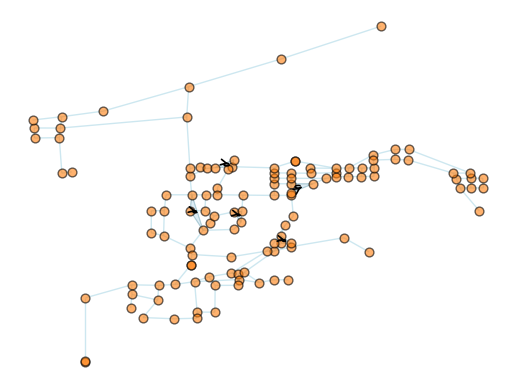

In [14]:
from pytspl import SCPlot

ccplot = SCPlot(complex=complex, coordinates=coords, only_sc=only_sc)
ccplot.draw_network(
    with_labels=False,
    directed=False,        # no arrow clutter unless you need it
    draw_orientation=True, # keep polygon arrows
    node_size=40,
    edge_width=1.0,
    arrowsize=6,
    alpha=0.6,
)